# Waste Classification

## Project Objective

This project aims to build a deep learning image classification system that can automatically classify waste into five material categories:

* Plastic
* Paper
* Glass
* Metal
* Organic

The project uses real-world photographs of waste items, where images may have different backgrounds, lighting conditions, angles, and object appearances.

## Real-World Problem

Waste sorting is an important part of recycling. Manually sorting different types of waste can be time-consuming and difficult. A computer vision system can help automatically identify the material type of a waste item and support automated recycling systems, smart bins, and waste-sorting applications.

## Approach

This is a multiclass image classification problem. The project will use Convolutional Neural Networks (CNNs) and, primarily, transfer learning.

Three approaches will be compared:

1. Custom CNN trained from scratch as a baseline.
2. MobileNetV2 using transfer learning.
3. EfficientNetB0 using transfer learning.

The pretrained MobileNetV2 and EfficientNetB0 models have already learned useful visual features from the ImageNet dataset. These features can be adapted to the waste-classification task.

## Why Transfer Learning?

The waste dataset contains only a few thousand images, which is relatively small for training a large CNN from scratch. Transfer learning allows us to reuse knowledge learned from a large dataset and adapt it to the five waste categories.

The project will use a two-phase transfer-learning approach:

* **Phase 1:** Freeze the pretrained base model and train the new classifier head.
* **Phase 2:** Unfreeze some of the later layers and fine-tune them using a very low learning rate.

## Project Goal

The goal is to develop an accurate and practical waste-classification model and compare different deep learning architectures using accuracy, macro-F1 score, confusion matrix, model size, and inference time.

The final model will be evaluated for its potential use in real-world waste-sorting and recycling applications.


In [1]:
# Step 2: Imports & Setup

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

# Set random seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Check TensorFlow version
print("TensorFlow version:", tf.__version__)

# Check available GPUs
gpus = tf.config.list_physical_devices("GPU")
print("GPUs detected:", gpus)

if gpus:
    print("GPU is available.")
else:
    print("GPU is not available. CPU will be used.")

TensorFlow version: 2.20.0
GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
GPU is available.


In [2]:
# Step 3: Load Data from Folders

import os
from collections import Counter

# Correct dataset path
DATA_DIR = "/kaggle/input/datasets/quangtheng/garbage-classification-6-classes-775class"

# Show folders
print("Folders in dataset:")
print(os.listdir(DATA_DIR))

# Five target classes
# Battery is excluded according to the guide
CLASS_NAMES = ["glass", "metal", "organic", "paper", "plastic"]

# Collect image paths and labels
image_paths = []
labels = []

for class_name in CLASS_NAMES:
    class_dir = os.path.join(DATA_DIR, class_name)

    for file_name in os.listdir(class_dir):
        file_path = os.path.join(class_dir, file_name)

        if file_name.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
            image_paths.append(file_path)
            labels.append(class_name)

# Print class names
print("\nClass names:")
print(CLASS_NAMES)

# Print per-class counts
print("\nPer-class image counts:")

class_counts = Counter(labels)

for class_name in CLASS_NAMES:
    print(f"{class_name}: {class_counts[class_name]}")

print("\nTotal images:", len(image_paths))

Folders in dataset:
['metal', 'glass', 'organic', 'paper', 'battery', 'plastic']

Class names:
['glass', 'metal', 'organic', 'paper', 'plastic']

Per-class image counts:
glass: 775
metal: 775
organic: 775
paper: 775
plastic: 775

Total images: 3875


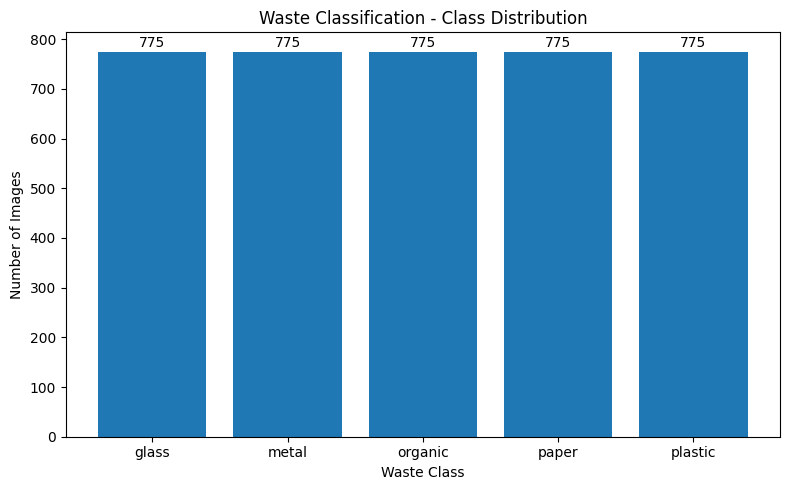

Naive baseline accuracy: 20%
This means random guessing among 5 balanced classes gives about 20% accuracy.


In [3]:
# Step 4: Class Distribution

import matplotlib.pyplot as plt

# Get counts for the five target classes
counts = [class_counts[class_name] for class_name in CLASS_NAMES]

# Plot class distribution
plt.figure(figsize=(8, 5))
bars = plt.bar(CLASS_NAMES, counts)

plt.title("Waste Classification - Class Distribution")
plt.xlabel("Waste Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

# Show values on top of bars
for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + 10,
        str(count),
        ha="center"
    )

plt.tight_layout()
plt.show()

# Naive baseline for 5 balanced classes
naive_baseline = 1 / len(CLASS_NAMES)

print(f"Naive baseline accuracy: {naive_baseline:.0%}")
print("This means random guessing among 5 balanced classes gives about 20% accuracy.")

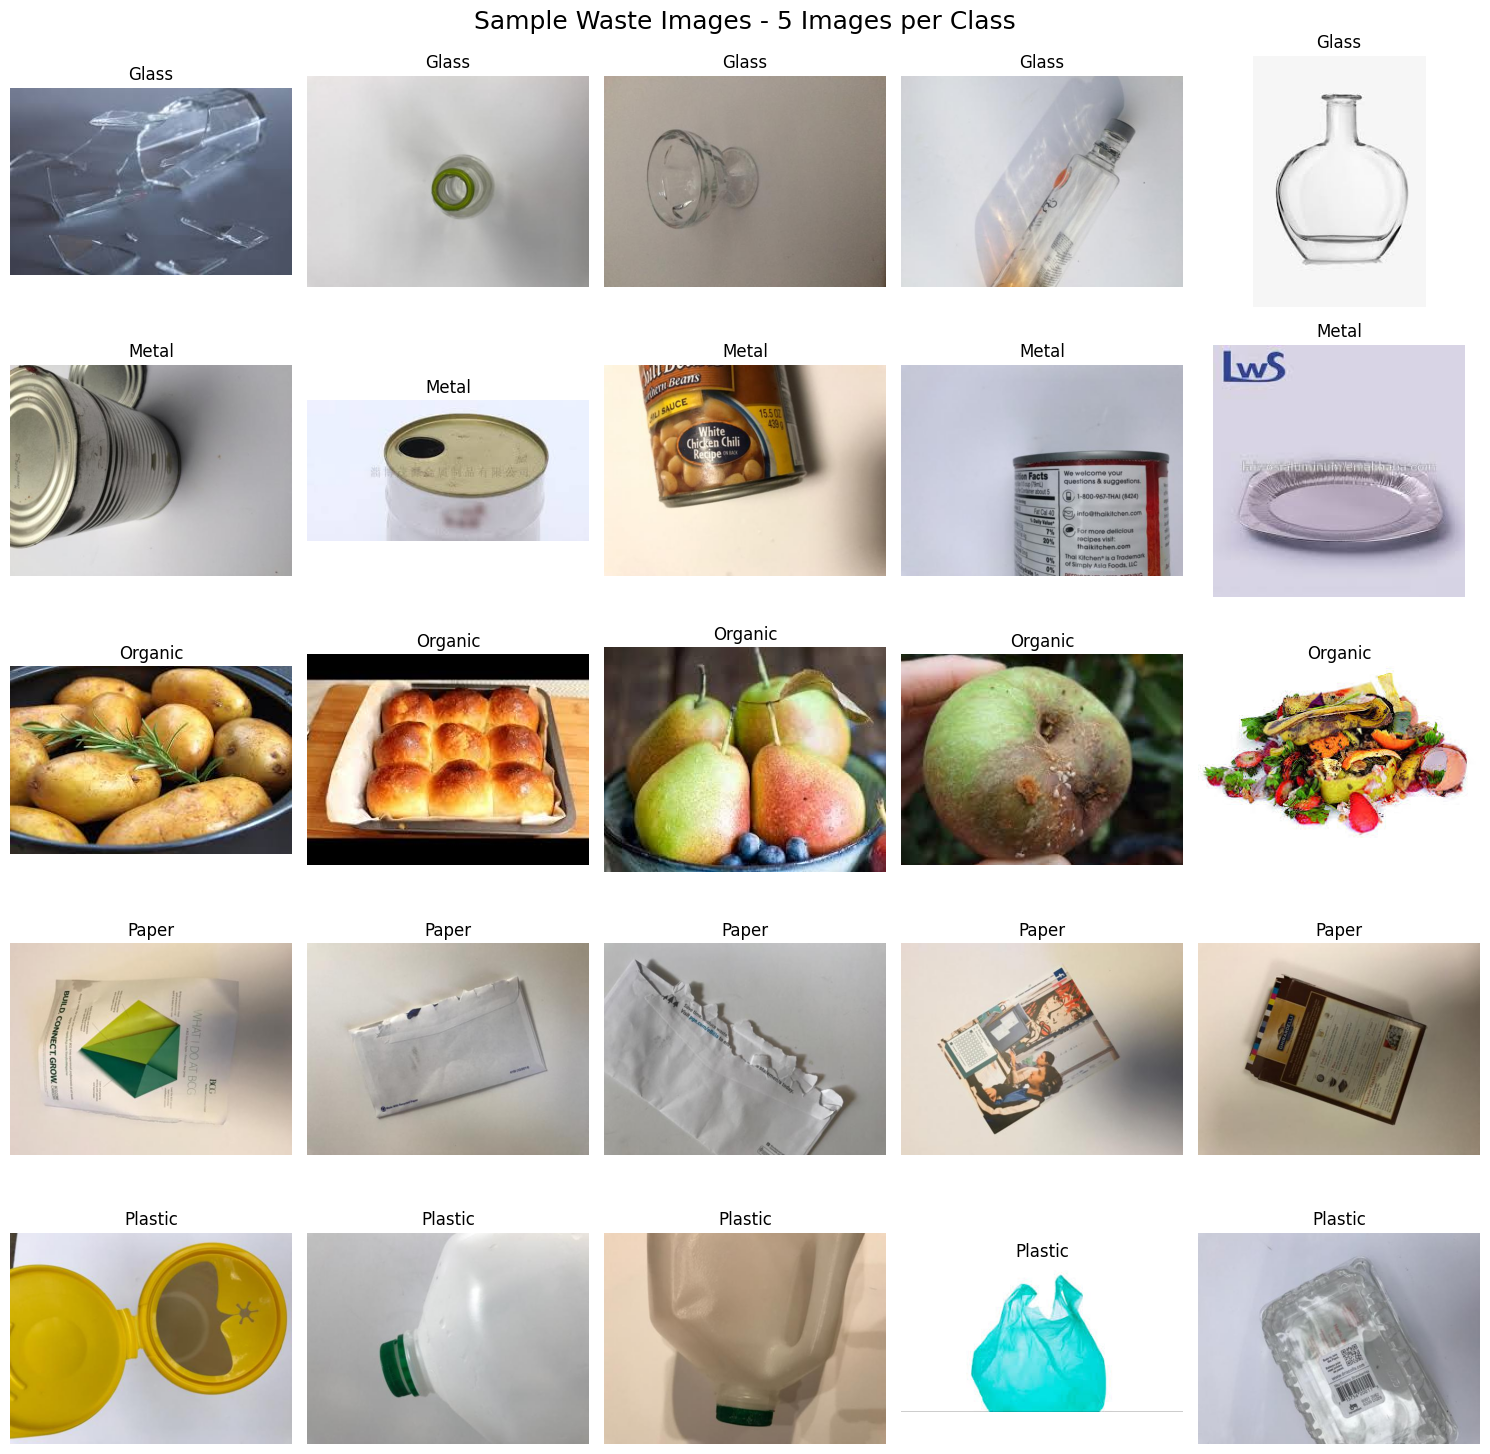

In [4]:
# Step 5: Sample Image Grid - 5 Images per Class

import random
from PIL import Image

images_per_class = 5

plt.figure(figsize=(15, 15))

plot_index = 1

for class_name in CLASS_NAMES:

    class_images = [
        path for path, label in zip(image_paths, labels)
        if label == class_name
    ]

    selected_images = random.sample(class_images, images_per_class)

    for image_path in selected_images:

        image = Image.open(image_path)

        plt.subplot(len(CLASS_NAMES), images_per_class, plot_index)
        plt.imshow(image)
        plt.title(class_name.capitalize())
        plt.axis("off")

        plot_index += 1

plt.suptitle(
    "Sample Waste Images - 5 Images per Class",
    fontsize=18
)

plt.tight_layout()
plt.show()

Resolution & Aspect Ratio Analysis
---------------------------------------------
Minimum width: 114
Maximum width: 512
Minimum height: 106
Maximum height: 400

Average width: 385.78
Average height: 300.84
Average aspect ratio: 1.29


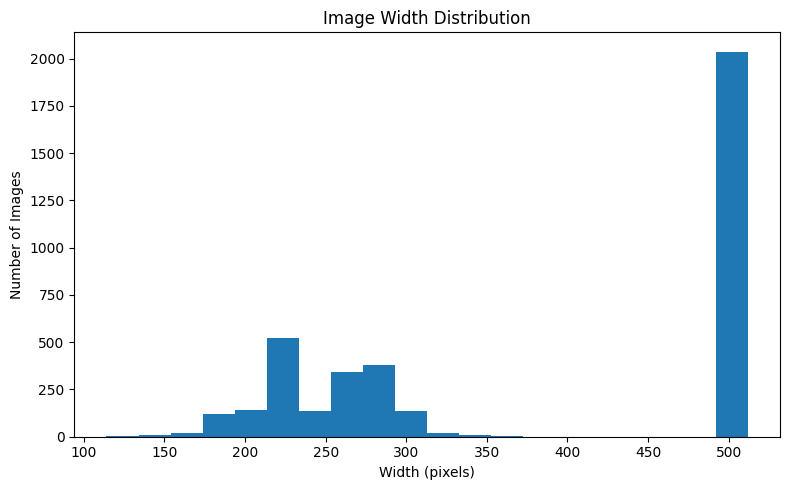

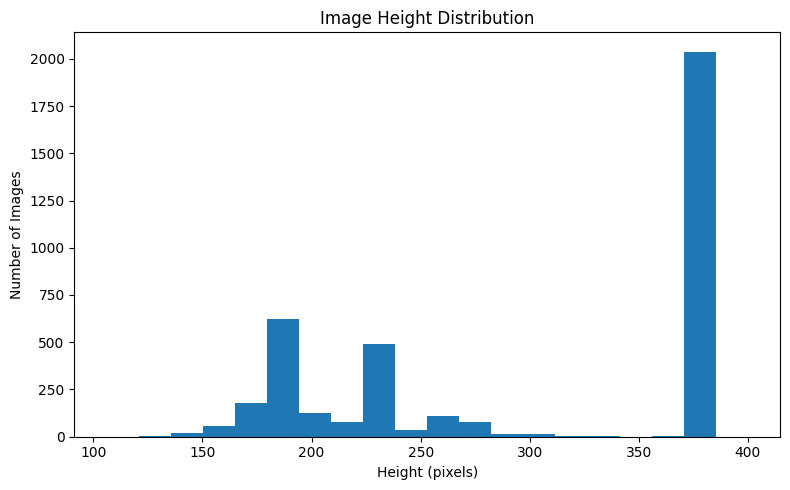

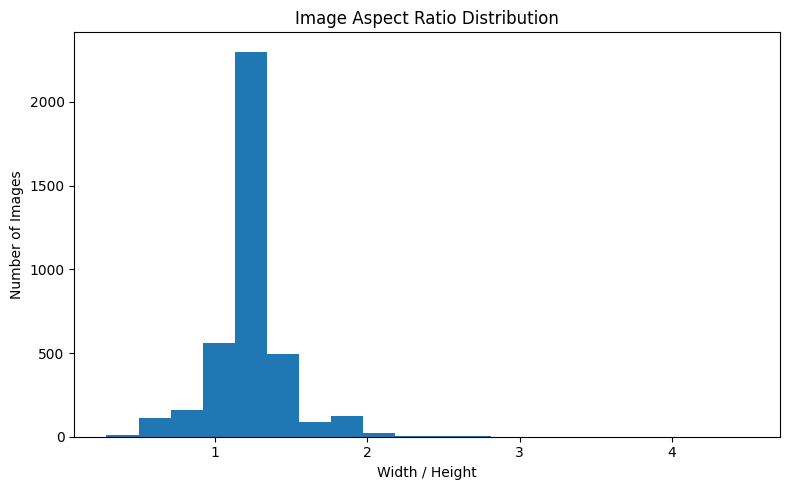


Visual cues to observe:
- Glass: transparency, reflections, and highlights
- Metal: reflectivity, shiny surfaces, and edges
- Organic: irregular shapes, natural textures, and varied colors
- Paper: matte surfaces, flat shapes, and light textures
- Plastic: smooth surfaces, varied shapes, and sometimes transparency


In [5]:
# Step 6: Resolution & Visual Cue EDA

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Store image dimensions
widths = []
heights = []
aspect_ratios = []

# Check all images
for image_path in image_paths:
    with Image.open(image_path) as img:
        width, height = img.size

        widths.append(width)
        heights.append(height)
        aspect_ratios.append(width / height)

# Print resolution information
print("Resolution & Aspect Ratio Analysis")
print("-" * 45)

print(f"Minimum width: {min(widths)}")
print(f"Maximum width: {max(widths)}")
print(f"Minimum height: {min(heights)}")
print(f"Maximum height: {max(heights)}")

print(f"\nAverage width: {np.mean(widths):.2f}")
print(f"Average height: {np.mean(heights):.2f}")
print(f"Average aspect ratio: {np.mean(aspect_ratios):.2f}")

# Plot width distribution
plt.figure(figsize=(8, 5))
plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

# Plot height distribution
plt.figure(figsize=(8, 5))
plt.hist(heights, bins=20)
plt.title("Image Height Distribution")
plt.xlabel("Height (pixels)")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

# Plot aspect ratio distribution
plt.figure(figsize=(8, 5))
plt.hist(aspect_ratios, bins=20)
plt.title("Image Aspect Ratio Distribution")
plt.xlabel("Width / Height")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

print("\nVisual cues to observe:")
print("- Glass: transparency, reflections, and highlights")
print("- Metal: reflectivity, shiny surfaces, and edges")
print("- Organic: irregular shapes, natural textures, and varied colors")
print("- Paper: matte surfaces, flat shapes, and light textures")
print("- Plastic: smooth surfaces, varied shapes, and sometimes transparency")

# Step 7: EDA Findings

## Exploratory Data Analysis Findings

The dataset contains **3,875 images** across five target waste classes:

- Glass: 775 images
- Metal: 775 images
- Organic: 775 images
- Paper: 775 images
- Plastic: 775 images

The class distribution is perfectly balanced, with 775 images in each class. Therefore, the naive baseline accuracy for random guessing across five balanced classes is **20%**.

The images have different resolutions and aspect ratios. The observed image widths range from 114 to 512 pixels, while heights range from 106 to 400 pixels. The average aspect ratio is approximately 1.29. Therefore, resizing the images to a common size will be necessary before training the deep learning models.

Some classes have visually similar characteristics. Glass and plastic can both be transparent or reflective, while metal and glass may both contain strong highlights and reflections. Organic waste has more irregular shapes and natural textures, whereas paper generally has flatter and more matte surfaces.

These observations support the use of **Convolutional Neural Networks (CNNs)** and **transfer learning** for learning useful visual features for waste classification.

In [6]:
# Step 8: Preprocessing & Stratified Train/Validation/Test Split

import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Image size
IMG_SIZE = (224, 224)

# Five target classes only
# Battery is excluded
CLASS_NAMES = ["glass", "metal", "organic", "paper", "plastic"]

# Create numeric labels
class_to_index = {
    class_name: index
    for index, class_name in enumerate(CLASS_NAMES)
}

numeric_labels = np.array([
    class_to_index[label]
    for label in labels
])

image_paths_array = np.array(image_paths)

# --------------------------------------------------
# 70% Training, 15% Validation, 15% Test
# Stratified split keeps classes balanced
# --------------------------------------------------

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths_array,
    numeric_labels,
    test_size=0.30,
    random_state=SEED,
    stratify=numeric_labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

# --------------------------------------------------
# Create TensorFlow datasets directly from paths
# This prevents the battery folder from being loaded
# --------------------------------------------------

BATCH_SIZE = 32

def load_and_preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    return image, label


train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

train_ds = (
    train_ds
    .shuffle(len(train_paths), seed=SEED)
    .map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# --------------------------------------------------
# Final check
# --------------------------------------------------

print("Image size:", IMG_SIZE)
print("-" * 45)
print("Classes:", CLASS_NAMES)
print("Battery: EXCLUDED")
print("-" * 45)
print("Training images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Test images:", len(test_paths))
print("Total images:", len(train_paths) + len(val_paths) + len(test_paths))

I0000 00:00:1789032269.409254      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789032269.412050      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Image size: (224, 224)
---------------------------------------------
Classes: ['glass', 'metal', 'organic', 'paper', 'plastic']
Battery: EXCLUDED
---------------------------------------------
Training images: 2712
Validation images: 581
Test images: 582
Total images: 3875


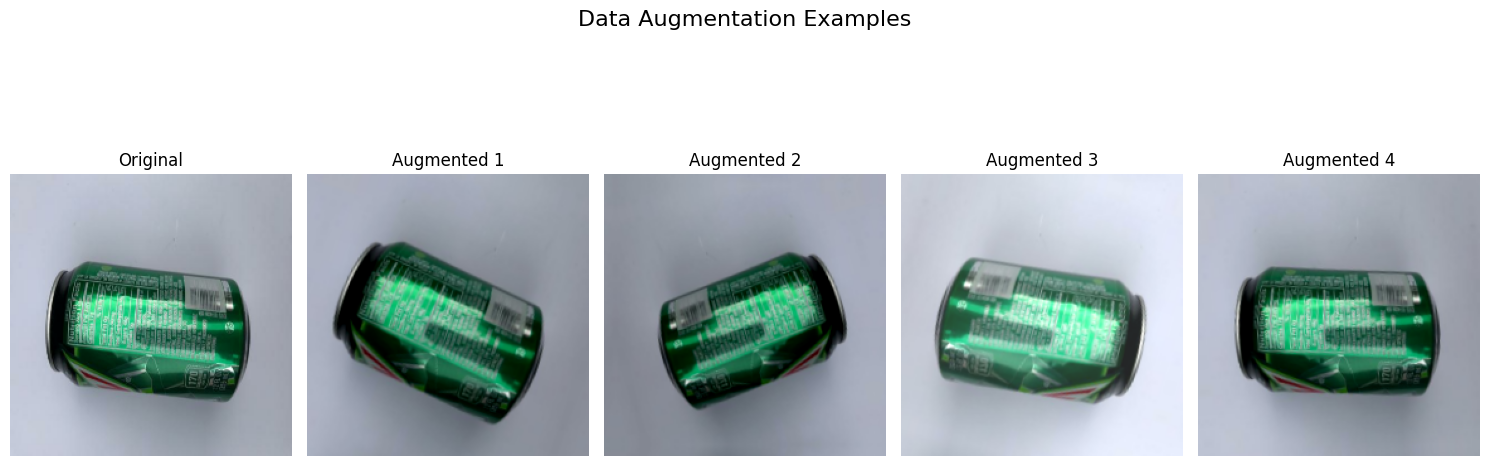

In [7]:
# Step 9: Data Augmentation Setup

from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Data augmentation layers
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.2)
], name="data_augmentation")

# Take one image from the training dataset
for images, labels_batch in train_ds.take(1):
    sample_image = images[0]
    break

# Display original and augmented versions
plt.figure(figsize=(15, 6))

for i in range(5):
    plt.subplot(1, 5, i + 1)

    if i == 0:
        display_image = sample_image
        title = "Original"
    else:
        display_image = data_augmentation(
            tf.expand_dims(sample_image, 0),
            training=True
        )[0]
        title = f"Augmented {i}"

    plt.imshow(tf.cast(display_image, tf.uint8))
    plt.title(title)
    plt.axis("off")

plt.suptitle("Data Augmentation Examples", fontsize=16)
plt.tight_layout()
plt.show()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.3650 - loss: 1.5470 - val_accuracy: 0.4836 - val_loss: 1.2682
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.4071 - loss: 1.3365 - val_accuracy: 0.4492 - val_loss: 1.3090
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.4594 - loss: 1.2709 - val_accuracy: 0.4785 - val_loss: 1.1883
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.5066 - loss: 1.1949 - val_accuracy: 0.5301 - val_loss: 1.1025
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.5206 - loss: 1.1541 - val_accuracy: 0.5473 - val_loss: 1.0435
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.5468 - loss: 1.1128 - val_accuracy: 0.6127 - val_loss: 0.9798
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.5350 - loss: 1.1096 - val_accuracy: 0.5783 - val_loss: 1.0829
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.5745 - loss: 1.0365 - val_accuracy: 0.5972 - 

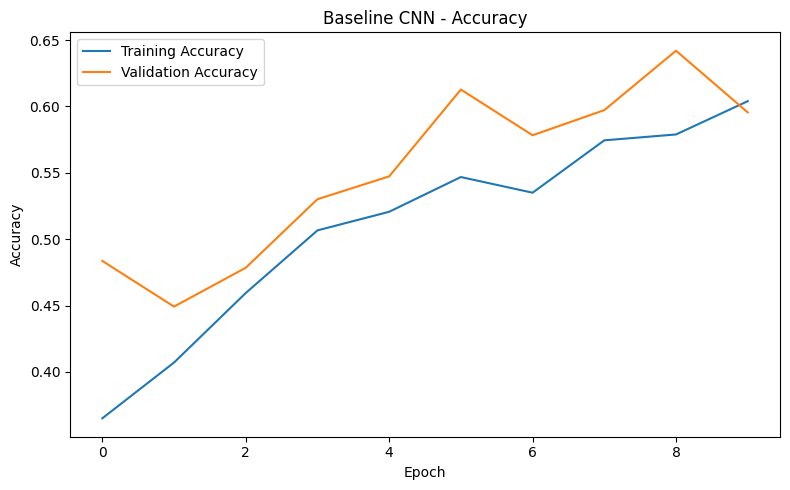

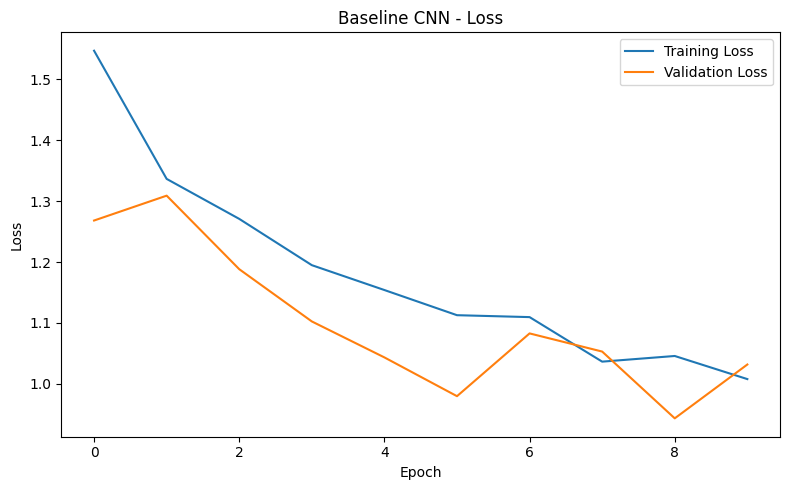

In [8]:
# Step 10: Baseline Custom CNN from Scratch

# Build a small CNN
baseline_model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Data augmentation
    data_augmentation,

    # Rescale pixel values
    layers.Rescaling(1./255),

    # CNN Block 1
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    # CNN Block 2
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    # CNN Block 3
    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    # Classifier
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(5, activation="softmax")
])

# Compile the model
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display model architecture
baseline_model.summary()

# Train the baseline CNN
baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(baseline_history.history["accuracy"], label="Training Accuracy")
plt.plot(baseline_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Baseline CNN - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(baseline_history.history["loss"], label="Training Loss")
plt.plot(baseline_history.history["val_loss"], label="Validation Loss")
plt.title("Baseline CNN - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.2378 - loss: 1.6956 - val_accuracy: 0.4596 - val_loss: 1.3821
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.2736 - loss: 1.5939 - val_accuracy: 0.6059 - val_loss: 1.0818
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.3031 - loss: 1.5329 - val_accuracy: 0.6799 - val_loss: 0.9632
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.3278 - loss: 1.5062 - val_accuracy: 0.7074 - val_loss: 0.8488
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.3289 - loss: 1.4934 - val_accuracy: 0.7315 - val_loss: 0.7619
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.3186 - loss: 1.4924 - val_accuracy: 0.7315 - val_loss: 0.7278
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.3455 - loss: 1.4588 - val_accuracy: 0.7797 - val_loss: 0.6843
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.3385 - loss: 1.4616 - val_accuracy: 0.8072 - 

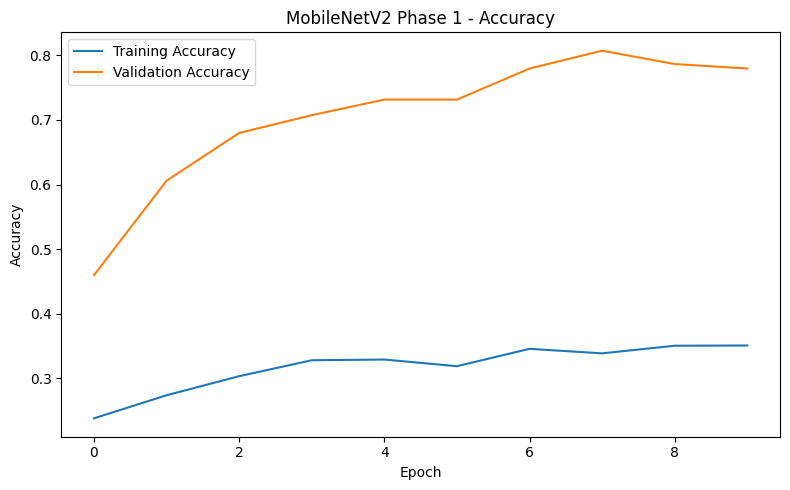

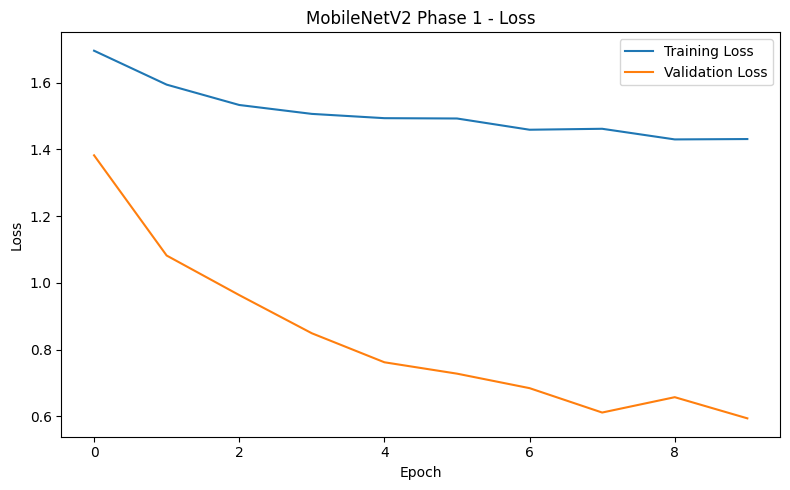

In [9]:
# Step 11: MobileNetV2 - Phase 1 Transfer Learning

# Create MobileNetV2-specific preprocessed datasets
mobilenet_train_ds = train_ds.map(
    lambda x, y: (mobilenet_preprocess(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

mobilenet_val_ds = val_ds.map(
    lambda x, y: (mobilenet_preprocess(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

mobilenet_test_ds = test_ds.map(
    lambda x, y: (mobilenet_preprocess(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Load pretrained MobileNetV2
base_mobilenet = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained base
base_mobilenet.trainable = False

# Build MobileNetV2 model
inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = base_mobilenet(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.2)(x)

outputs = layers.Dense(
    5,
    activation="softmax"
)(x)

mobilenet_model = keras.Model(
    inputs,
    outputs
)

# Compile model
mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Show model summary
mobilenet_model.summary()

# Train Phase 1
mobilenet_phase1_history = mobilenet_model.fit(
    mobilenet_train_ds,
    validation_data=mobilenet_val_ds,
    epochs=10
)

# Plot accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    mobilenet_phase1_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    mobilenet_phase1_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("MobileNetV2 Phase 1 - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Plot loss
plt.figure(figsize=(8, 5))

plt.plot(
    mobilenet_phase1_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    mobilenet_phase1_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("MobileNetV2 Phase 1 - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 1,785,541 (6.81 MB)

 Non-trainable params: 478,848 (1.83 MB)

Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - accuracy: 0.3566 - loss: 1.4022 - val_accuracy: 0.8141 - val_loss: 0.5600
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - accuracy: 0.3625 - loss: 1.3917 - val_accuracy: 0.7986 - val_loss: 0.5739
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - accuracy: 0.3654 - loss: 1.3688 - val_accuracy: 0.8055 - val_loss: 0.5533
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - accuracy: 0.3669 - loss: 1.3586 - val_accuracy: 0.8193 - val_loss: 0.5308
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - accuracy: 0.3643 - loss: 1.3674 - val_accuracy: 0.8296 - val_loss: 0.5230
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - accuracy: 0.3695 - loss: 1.3493 - val_accuracy: 0.8244 - val_loss: 0.5189
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - accuracy: 0.3566 - loss: 1.3608 - val_accuracy: 0.8210 - val_loss: 0.5141
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - accuracy: 0.3857 - loss: 1.3219 - val_accuracy: 0.8193 - 

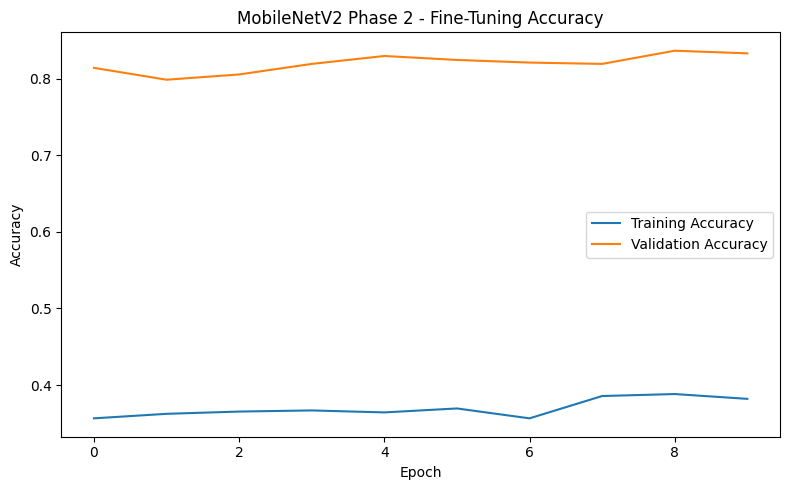

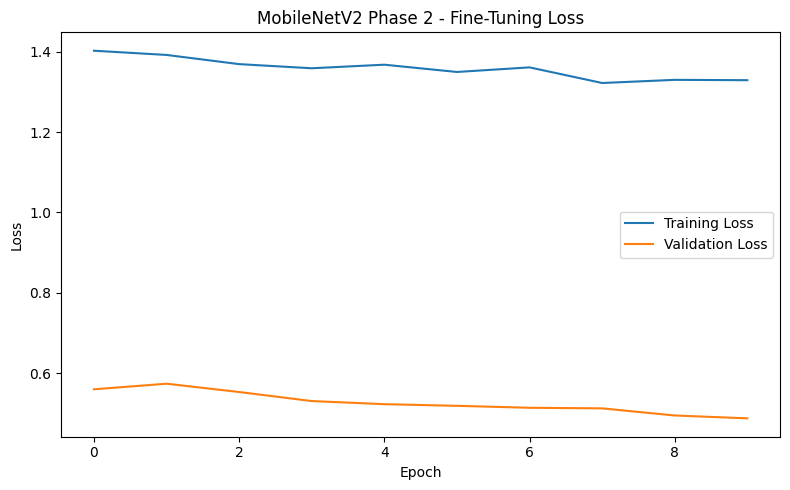

In [10]:
# Step 12: MobileNetV2 - Phase 2 Fine-Tuning

# Unfreeze MobileNetV2 base model
base_mobilenet.trainable = True

# Unfreeze approximately the last 30% of layers
fine_tune_at = int(len(base_mobilenet.layers) * 0.70)

for layer in base_mobilenet.layers[:fine_tune_at]:
    layer.trainable = False

# Keep BatchNormalization layers frozen for stable fine-tuning
for layer in base_mobilenet.layers[fine_tune_at:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Recompile with a very low learning rate
mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Check trainable parameters
mobilenet_model.summary()

# Fine-tune the model
mobilenet_phase2_history = mobilenet_model.fit(
    mobilenet_train_ds,
    validation_data=mobilenet_val_ds,
    epochs=10
)

# Plot accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    mobilenet_phase2_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    mobilenet_phase2_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("MobileNetV2 Phase 2 - Fine-Tuning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Plot loss
plt.figure(figsize=(8, 5))

plt.plot(
    mobilenet_phase2_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    mobilenet_phase2_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("MobileNetV2 Phase 2 - Fine-Tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()